LOGISTIC REGRESSION - EXERCISE

   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              0     1                      0      sales   

   salary  
0     low  
1  medium  
2 

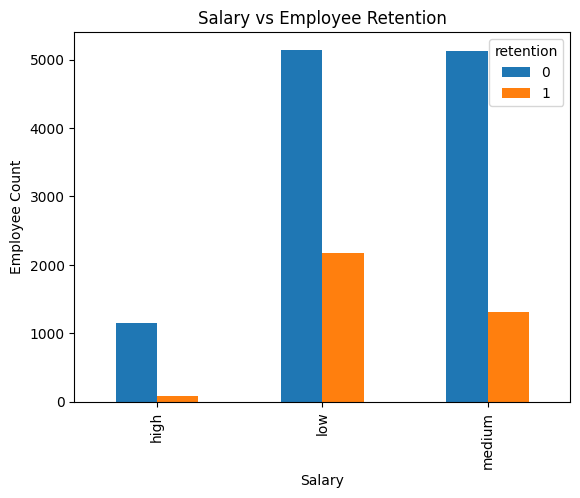

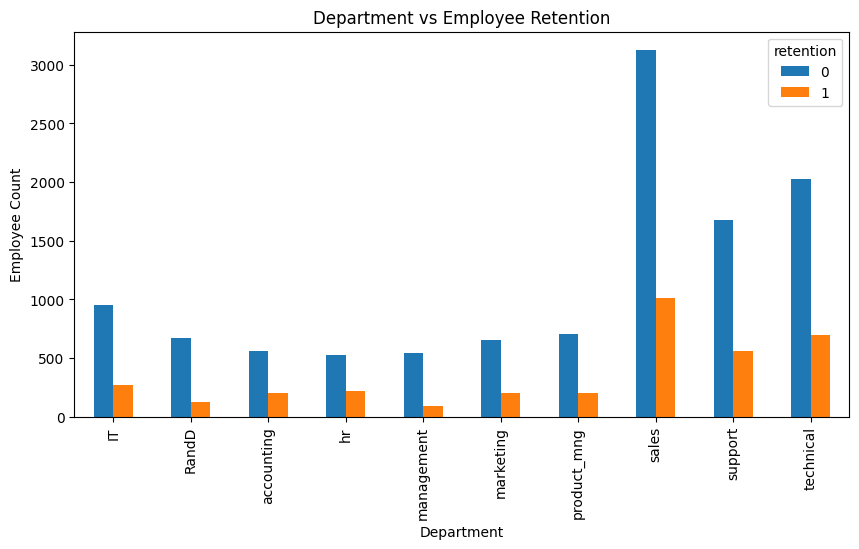

/tmp/ipykernel_1071/1476127509.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf['salary'] = le.fit_transform(subdf['salary'])


Model Accuracy = 0.7656666666666667


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv("/content/HR_comma_sep.csv")

# Display first rows
print(df.head())

# Rename target column for simplicity
df.rename(columns={'left':'retention'}, inplace=True)

# 0 = Stayed, 1 = Left
print(df['retention'].value_counts())

# ---------------- EDA ----------------

# Average values grouped by retention
print(df.groupby('retention').mean(numeric_only=True))

# ---------------- Salary vs Retention ----------------

salary_retention = pd.crosstab(df.salary, df.retention)

salary_retention.plot(kind='bar')
plt.title("Salary vs Employee Retention")
plt.xlabel("Salary")
plt.ylabel("Employee Count")
plt.show()

# ---------------- Department vs Retention ----------------

dept_retention = pd.crosstab(df.Department, df.retention)

dept_retention.plot(kind='bar', figsize=(10,5))
plt.title("Department vs Employee Retention")
plt.xlabel("Department")
plt.ylabel("Employee Count")
plt.show()

# ---------------- Feature Selection ----------------

# Variables having major impact
subdf = df[['satisfaction_level',
            'average_montly_hours',
            'promotion_last_5years',
            'salary']]

# Convert salary text into numbers
le = LabelEncoder()
subdf['salary'] = le.fit_transform(subdf['salary'])

# Input and output
X = subdf
y = df['retention']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=10
)

# ---------------- Logistic Regression ----------------

model = LogisticRegression()

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy =", accuracy)

In [ ]:
LOGISTIC REGRESSION ON PS DATASET

In [7]:
import pandas as pd
import random
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df = pd.read_csv("/content/T3 - driver_text_dataset_.csv")

# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
df['text'] = df['text'].fillna('')

# Add small noise for realistic accuracy
random_indices = random.sample(range(len(df)), 30)

possible_labels = [
    'normal',
    'fatigue',
    'drowsy',
    'stress',
    'distraction',
    'emergency'
]

for i in random_indices:
    df.at[i, 'label'] = random.choice(possible_labels)
df['text'] = df['text'].fillna('')
# Features and target
X = df['text']
y = df['label']

# TF-IDF Vectorization
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=500,
    ngram_range=(1,2)
)

X = tfidf.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Logistic Regression Model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, pred)

print("Accuracy:", acc)

# Classification Report
print(classification_report(y_test, pred))

Accuracy: 0.25
              precision    recall  f1-score   support

 distraction       0.00      0.00      0.00         2
      drowsy       0.25      1.00      0.40         3
   emergency       0.00      0.00      0.00         2
     fatigue       0.00      0.00      0.00         2
      normal       0.00      0.00      0.00         2
      stress       0.00      0.00      0.00         1

    accuracy                           0.25        12
   macro avg       0.04      0.17      0.07        12
weighted avg       0.06      0.25      0.10        12



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
